# Road Safety Data Analysis (UK)

## Business Problem

Road traffic accidents are a major public safety concern. By analyzing historical road safety data, we can identify accident patterns, high-risk conditions, and factors contributing to accident severity.

---

## Objectives

- Explore road accident trends.
- Analyze accident severity.
- Investigate vehicle and casualty characteristics.
- Identify temporal and environmental patterns.
- Generate insights to support road safety improvements.

---

## Dataset Description

This project uses the UK Road Safety datasets:

- **Collision Dataset:** Information about each accident.
- **Vehicle Dataset:** Information about vehicles involved.
- **Casualty Dataset:** Information about casualties involved.

Each dataset is linked using **accident_index**.

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
import matplotlib.gridspec as gridspec
from IPython.display import Markdown

# Consistent color palette used across every chart
COLORS = {
    "Fatal": "#C0392B", "Serious": "#E67E22", "Slight": "#2980B9",
    "primary": "#2C3E50", "accent": "#16A085", "muted": "#95A5A6",
}
SEVERITY_ORDER = ["Fatal", "Serious", "Slight"]

def style_ax(ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", color=COLORS["primary"], pad=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

## 2. Load the data

In [3]:
# Load Datasets

collisions_df = pd.read_csv(
    r"D:\DEPI\Data Analysis\Final Project\Road_Safety_Analysis\data\collision.csv",
    low_memory=False
)

vehicles_df = pd.read_csv(
    r"D:\DEPI\Data Analysis\Final Project\Road_Safety_Analysis\data\vehicle.csv",
    low_memory=False
)

casualties_df = pd.read_csv(
    r"D:\DEPI\Data Analysis\Final Project\Road_Safety_Analysis\data\casualty.csv",
    low_memory=False
)

print("Collisions :", collisions_df.shape)
print("Vehicles   :", vehicles_df.shape)
print("Casualties :", casualties_df.shape)

Collisions : (503475, 44)
Vehicles   : (920692, 32)
Casualties : (640522, 23)


## 3. Initial Data Inspection

In [4]:
# Information about each dataset

print("Collisions")
print(collisions_df.info())

print("\n" + "="*50 + "\n")

print("Vehicles")
print(vehicles_df.info())

print("\n" + "="*50 + "\n")

print("Casualties")
print(casualties_df.info())

Collisions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64 

In [5]:
# First 5 rows

print("Collisions")
display(collisions_df.head())

print("Vehicles")
display(vehicles_df.head())

print("Casualties")
display(casualties_df.head())

Collisions


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.00,532997.00,-1.27,54.69,17,3,2,2,22/05/2021,7,22:44,-1,E06000001,E06000001,E06000001,6,0,6,60,0,0,-1,0,-1,0,0,0,6,1,1,0,0,0,2,1,2,E01011959,-1,0,0.29,0.71
1,2021170H11231,2021,170H11231,450486.00,533118.00,-1.22,54.69,17,3,2,1,20/10/2021,4,15:50,-1,E06000001,E06000001,E06000001,4,1277,6,30,6,16,2,5,0,0,0,0,1,1,1,0,0,0,1,2,2,E01011973,-1,0,0.02,0.98
2,2020170M11750,2020,170M11750,449694.00,519733.00,-1.23,54.57,17,3,2,1,01/12/2020,3,18:00,243,E06000002,E06000002,E06000002,6,0,6,20,6,16,4,6,0,0,0,0,4,1,1,0,0,0,1,1,2,E01012092,-1,0,0.13,0.87
3,2021170M31761,2021,170M31761,449744.00,514217.00,-1.23,54.52,17,3,1,1,09/12/2021,5,16:55,-1,E06000002,E06000002,E06000002,5,0,6,40,0,0,-1,0,-1,0,0,0,4,1,2,0,0,0,2,1,2,E01032553,-1,0,0.18,0.82
4,2021170S10441,2021,170S10441,445971.00,520834.00,-1.29,54.58,17,3,3,1,12/04/2021,2,09:02,-1,E06000004,E06000004,E06000004,3,19,3,70,0,0,-1,0,-1,0,0,0,1,1,1,4,0,13,2,1,1,E01012258,-1,0,0.02,0.98


Vehicles


,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane_historic,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver_historic,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2020210979534,2020,210979534,2,5,0,3,3,4,6,0,0,0,0,0,0,0,2,1,5,6,1,57,9,798,1,4,BMW F 800,3,E01010422,0,-1
1,2020030959800,2020,030959800,1,5,0,17,19,2,6,0,0,0,0,0,1,0,1,1,6,6,1,59,9,798,1,3,BMW F 800,6,E01025351,0,-1
2,2020360978858,2020,360978858,2,5,0,18,19,8,4,0,0,0,5,0,0,0,1,1,2,2,1,64,9,798,1,11,BMW F 800,4,E01026874,0,-1
3,2020430340711,2020,430340711,1,5,0,18,19,3,7,0,0,0,0,0,7,4,1,1,6,6,1,48,8,798,1,8,BMW F 800,8,E01017758,0,-1
4,2020010260297,2020,010260297,1,5,0,99,99,9,9,99,99,0,9,99,9,99,9,1,2,2,1,36,7,798,1,9,BMW F 800,8,E01016121,0,-1


Casualties


,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2020010280094,2020,010280094,1,1,3,2,24,5,3,8,9,0,0,0,0,3,E01003536,-1,0,0.00,1.00,-1
1,202031D109620,2020,31D109620,1,1,3,2,95,11,2,5,1,0,0,0,0,6,E01028156,-1,0,1.00,0.00,-1
2,2020401003715,2020,401003715,1,1,3,1,39,7,3,5,1,0,0,0,0,2,E01017492,3,1,0.00,1.00,-1
3,2021201086330,2021,201086330,1,1,3,1,63,9,3,6,9,0,0,2,0,3,E01009140,3,1,0.00,1.00,-1
4,2021371050963,2021,371050963,1,1,3,1,51,8,3,9,9,0,0,0,0,9,E01030190,3,1,0.00,1.00,-1


In [6]:
# Missing Values

print("Collisions")
display(collisions_df.isnull().sum())

print("\nVehicles")
display(vehicles_df.isnull().sum())

print("\nCasualties")
display(casualties_df.isnull().sum())

Collisions


collision_index                                      0
collision_year                                       0
collision_ref_no                                     0
location_easting_osgr                               65
location_northing_osgr                              65
longitude                                           65
latitude                                            65
police_force                                         0
collision_severity                                   0
number_of_vehicles                                   0
number_of_casualties                                 0
date                                                 0
day_of_week                                          0
time                                                 0
local_authority_district                             0
local_authority_ons_district                         0
local_authority_highway                              0
local_authority_highway_current                     80
first_road


Vehicles


collision_index                              0
collision_year                               0
collision_ref_no                             0
vehicle_reference                            0
vehicle_type                                 0
towing_and_articulation                      0
vehicle_manoeuvre_historic                   0
vehicle_manoeuvre                            0
vehicle_direction_from                       0
vehicle_direction_to                         0
vehicle_location_restricted_lane_historic    0
vehicle_location_restricted_lane             0
junction_location                            0
skidding_and_overturning                     0
hit_object_in_carriageway                    0
vehicle_leaving_carriageway                  0
hit_object_off_carriageway                   0
first_point_of_impact                        0
vehicle_left_hand_drive                      0
journey_purpose_of_driver_historic           0
journey_purpose_of_driver                    0
sex_of_driver


Casualties


collision_index                       0
collision_year                        0
collision_ref_no                      0
vehicle_reference                     0
casualty_reference                    0
casualty_class                        0
sex_of_casualty                       0
age_of_casualty                       0
age_band_of_casualty                  0
casualty_severity                     0
pedestrian_location                   0
pedestrian_movement                   0
car_passenger                         0
bus_or_coach_passenger                0
pedestrian_road_maintenance_worker    0
casualty_type                         0
casualty_imd_decile                   0
lsoa_of_casualty                      0
enhanced_casualty_severity            0
casualty_injury_based                 0
casualty_adjusted_severity_serious    0
casualty_adjusted_severity_slight     0
casualty_distance_banding             0
dtype: int64

In [7]:
# Check Duplicate Rows

print("Collisions :", collisions_df.duplicated().sum())
print("Vehicles   :", vehicles_df.duplicated().sum())
print("Casualties :", casualties_df.duplicated().sum())

Collisions : 0
Vehicles   : 0
Casualties : 0


## 4. Data Cleaning

Parsing dates/times and mapping severity/condition codes to readable labels.

In [8]:
# Convert Date and Time

collisions_df["date"] = pd.to_datetime(
    collisions_df["date"],
    dayfirst=True
)

collisions_df["time"] = pd.to_datetime(
    collisions_df["time"],
    format="%H:%M"
).dt.time

print("Date and Time converted successfully.")

Date and Time converted successfully.


## 5. Feature Engineering

In [9]:
# Extract Features from Date

collisions_df["year"] = collisions_df["date"].dt.year
collisions_df["month"] = collisions_df["date"].dt.month
collisions_df["month_name"] = collisions_df["date"].dt.month_name()

collisions_df["day"] = collisions_df["date"].dt.day
collisions_df["day_name"] = collisions_df["date"].dt.day_name()

print(collisions_df[
    ["date","year","month","month_name","day","day_name"]
].head())

        date  year  month month_name  day   day_name
0 2021-05-22  2021      5        May   22   Saturday
1 2021-10-20  2021     10    October   20  Wednesday
2 2020-12-01  2020     12   December    1    Tuesday
3 2021-12-09  2021     12   December    9   Thursday
4 2021-04-12  2021      4      April   12     Monday


In [10]:
# Extract Hour

collisions_df["hour"] = pd.to_datetime(
    collisions_df["time"].astype(str)
).dt.hour

print(collisions_df[["time","hour"]].head())

       time  hour
0  22:44:00    22
1  15:50:00    15
2  18:00:00    18
3  16:55:00    16
4  09:02:00     9


In [11]:
# Time of Day

def time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


collisions_df["time_period"] = collisions_df["hour"].apply(time_period)

print(collisions_df[["hour","time_period"]].head())

   hour time_period
0    22       Night
1    15   Afternoon
2    18     Evening
3    16   Afternoon
4     9     Morning


In [12]:
# Season

def season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"


collisions_df["season"] = collisions_df["month"].apply(season)

print(collisions_df[["month_name","season"]].head())

  month_name  season
0        May  Spring
1    October  Autumn
2   December  Winter
3   December  Winter
4      April  Spring


In [13]:
# Check New Features

collisions_df[[
    "date",
    "year",
    "month_name",
    "day_name",
    "hour",
    "time_period",
    "season"
]].head()

,date,year,month_name,day_name,hour,time_period,season
0,2021-05-22,2021,May,Saturday,22,Night,Spring
1,2021-10-20,2021,October,Wednesday,15,Afternoon,Autumn
2,2020-12-01,2020,December,Tuesday,18,Evening,Winter
3,2021-12-09,2021,December,Thursday,16,Afternoon,Winter
4,2021-04-12,2021,April,Monday,9,Morning,Spring


## 6. Convert Codes to Readable Labels

In [14]:
# Convert Codes to Readable Labels

# Collision Severity
severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight"
}

collisions_df["collision_severity"] = collisions_df["collision_severity"].map(severity_map)


# Urban / Rural
area_map = {
    1: "Urban",
    2: "Rural",
    3: "Unknown"
}

collisions_df["urban_or_rural_area"] = collisions_df["urban_or_rural_area"].map(area_map)


# Light Conditions
light_map = {
    1: "Daylight",
    4: "Dark - Street lights lit",
    5: "Dark - Street lights unlit",
    6: "Dark - No street lighting",
    7: "Dark - Lighting unknown"
}

collisions_df["light_conditions"] = collisions_df["light_conditions"].map(light_map)


# Weather Conditions
weather_map = {
    1: "Fine",
    2: "Raining",
    3: "Snowing",
    4: "Fine & High Winds",
    5: "Raining & High Winds",
    6: "Snowing & High Winds",
    7: "Fog or Mist",
    8: "Other",
    9: "Unknown"
}

collisions_df["weather_conditions"] = collisions_df["weather_conditions"].map(weather_map)


# Road Surface
road_surface_map = {
    1: "Dry",
    2: "Wet or Damp",
    3: "Snow",
    4: "Frost or Ice",
    5: "Flood",
    6: "Oil or Diesel",
    7: "Mud"
}

collisions_df["road_surface_conditions"] = collisions_df["road_surface_conditions"].map(road_surface_map)

print("Done.")

Done.


In [15]:
collisions_df[
    [
        "collision_severity",
        "weather_conditions",
        "light_conditions",
        "road_surface_conditions",
        "urban_or_rural_area"
    ]
].head()

,collision_severity,weather_conditions,light_conditions,road_surface_conditions,urban_or_rural_area
0,Slight,Fine,Dark - No street lighting,Dry,Rural
1,Slight,Fine,Daylight,Dry,Urban
2,Slight,Fine,Dark - Street lights lit,Dry,Urban
3,Slight,Fine,Dark - Street lights lit,Wet or Damp,Rural
4,Slight,Fine,Daylight,Dry,Rural


## 7. Exploratory Data Analysis (EDA)

### 7.1 Distribution of Collision Severity

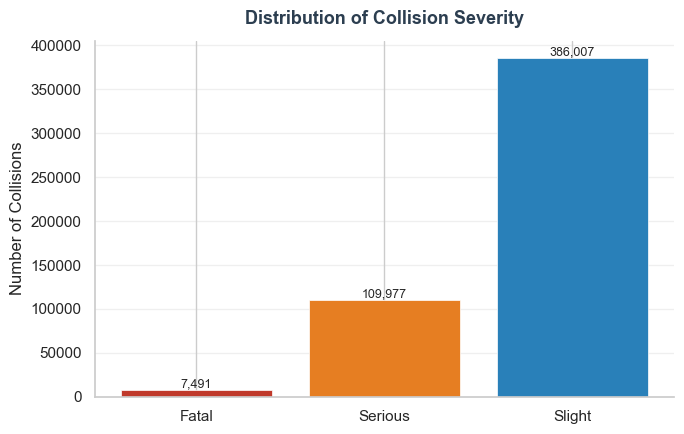

In [16]:
# Distribution of Collision Severity

severity = collisions_df["collision_severity"].value_counts().reindex(SEVERITY_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(severity.index, severity.values,
               color=[COLORS[s] for s in severity.index], edgecolor="white", linewidth=0.5)

for bar, v in zip(bars, severity.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

style_ax(ax, "Distribution of Collision Severity")
ax.set_xlabel("")
ax.set_ylabel("Number of Collisions")

plt.tight_layout()
plt.show()

In [17]:
top_sev = severity.idxmax()
display(Markdown(
    f"**Interpretation:** the majority of collisions are classed **{top_sev}** "
    f"({severity[top_sev] / severity.sum():.1%} of all collisions), while fatal collisions make "
    f"up **{severity['Fatal'] / severity.sum():.1%}** — a small share, but the highest-priority one."
))

**Interpretation:** the majority of collisions are classed **Slight** (76.7% of all collisions), while fatal collisions make up **1.5%** — a small share, but the highest-priority one.

### 7.2 Trends Over Time

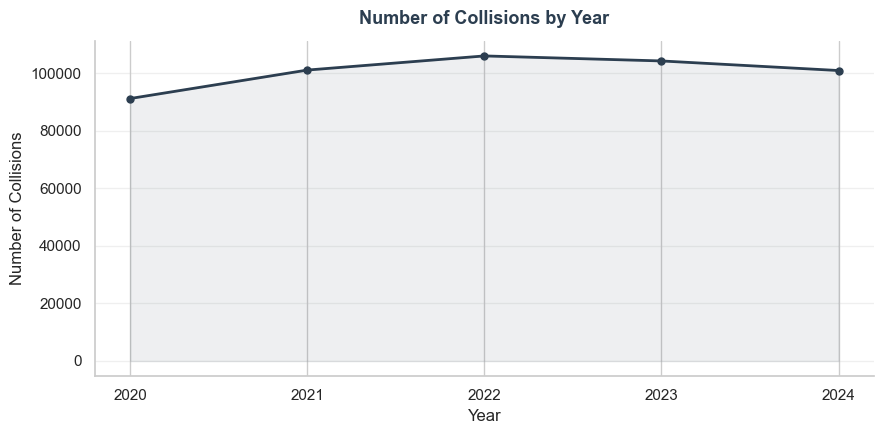

In [18]:
# Number of Collisions by Year

yearly = collisions_df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(yearly.index, yearly.values, marker="o", color=COLORS["primary"], linewidth=2, markersize=5)
ax.fill_between(yearly.index, yearly.values, color=COLORS["primary"], alpha=0.08)

style_ax(ax, "Number of Collisions by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Collisions")
ax.set_xticks(yearly.index)

plt.tight_layout()
plt.show()

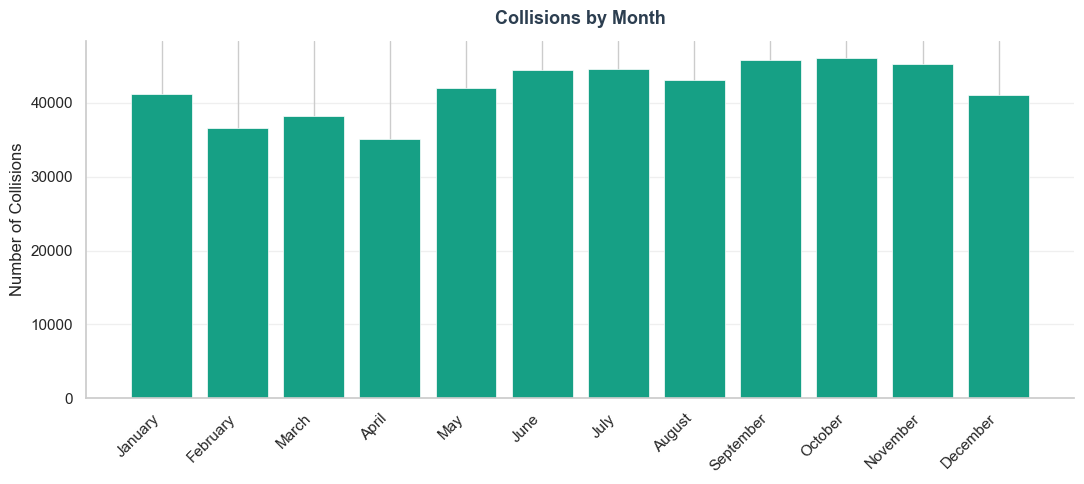

In [19]:
# Collisions by Month

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = (
    collisions_df["month_name"]
    .value_counts()
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(monthly.index, monthly.values, color=COLORS["accent"], edgecolor="white", linewidth=0.5)

style_ax(ax, "Collisions by Month")
ax.set_xlabel("")
ax.set_ylabel("Number of Collisions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

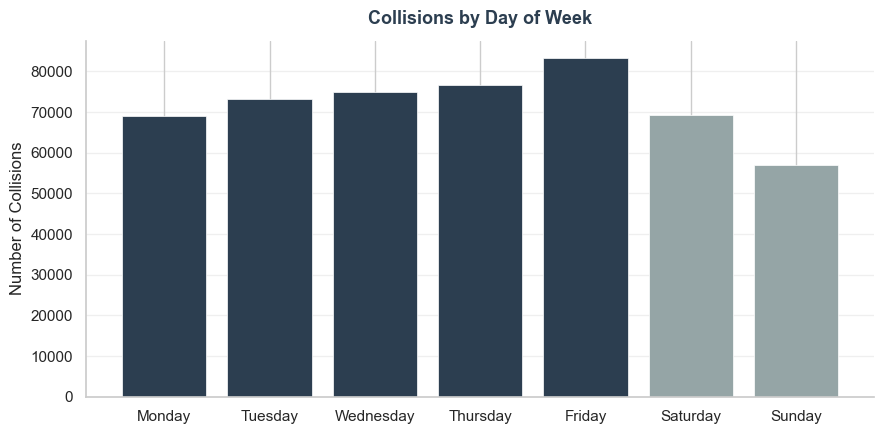

In [20]:
# Collisions by Day of Week

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

days = (
    collisions_df["day_name"]
    .value_counts()
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(9, 4.5))

weekday_colors = [COLORS["muted"] if d in ("Saturday", "Sunday") else COLORS["primary"] for d in day_order]
ax.bar(days.index, days.values, color=weekday_colors, edgecolor="white", linewidth=0.5)

style_ax(ax, "Collisions by Day of Week")
ax.set_xlabel("")
ax.set_ylabel("Number of Collisions")

plt.tight_layout()
plt.show()

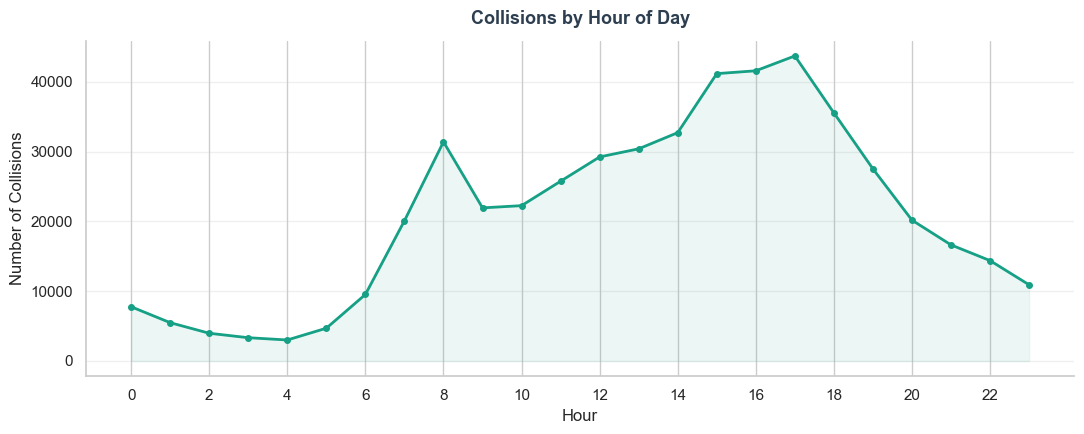

In [21]:
# Collisions by Hour

hourly = (
    collisions_df["hour"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(hourly.index, hourly.values, marker="o", color=COLORS["accent"], linewidth=2, markersize=4)
ax.fill_between(hourly.index, hourly.values, color=COLORS["accent"], alpha=0.08)

style_ax(ax, "Collisions by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Collisions")
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

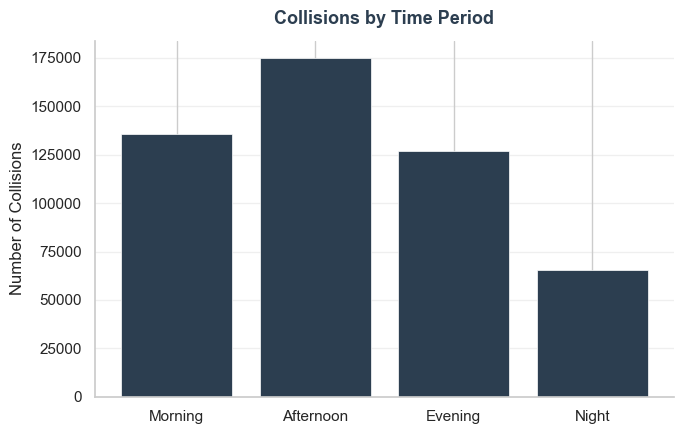

In [22]:
# Collisions by Time Period

order = ["Morning", "Afternoon", "Evening", "Night"]

period = (
    collisions_df["time_period"]
    .value_counts()
    .reindex(order)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(period.index, period.values, color=COLORS["primary"], edgecolor="white", linewidth=0.5)

style_ax(ax, "Collisions by Time Period")
ax.set_xlabel("")
ax.set_ylabel("Number of Collisions")

plt.tight_layout()
plt.show()

In [23]:
peak_year, peak_hour = yearly.idxmax(), hourly.idxmax()
display(Markdown(
    f"**Interpretation:** the busiest year on record is **{peak_year}**, and collisions peak "
    f"around **{peak_hour}:00**, consistent with commuting-hour traffic volume. Weekday counts "
    f"are visibly higher than the weekend, reinforcing that exposure (how much driving happens) "
    f"drives raw collision counts."
))

**Interpretation:** the busiest year on record is **2022**, and collisions peak around **17:00**, consistent with commuting-hour traffic volume. Weekday counts are visibly higher than the weekend, reinforcing that exposure (how much driving happens) drives raw collision counts.

### 7.3 Environmental & Road Conditions

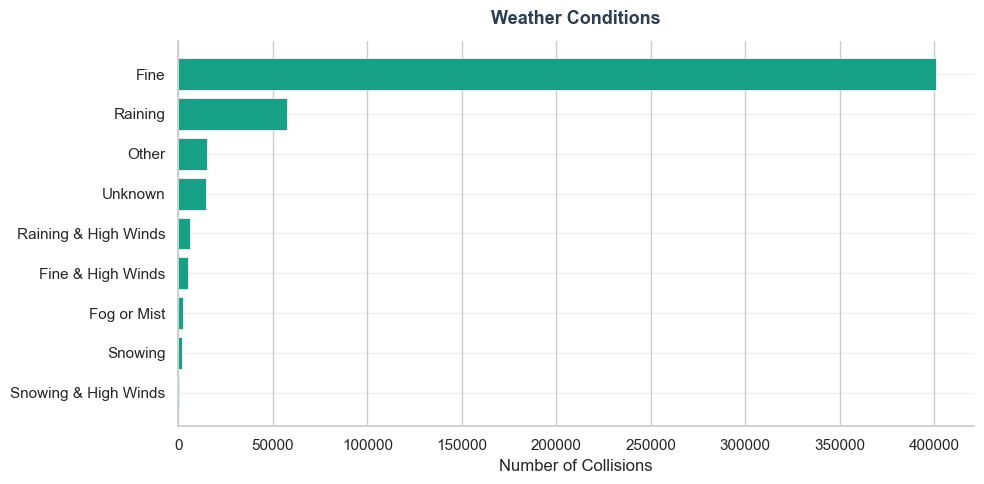

In [24]:
weather = collisions_df["weather_conditions"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(weather.index[::-1], weather.values[::-1], color=COLORS["accent"], edgecolor="white", linewidth=0.5)

style_ax(ax, "Weather Conditions")
ax.set_xlabel("Number of Collisions")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

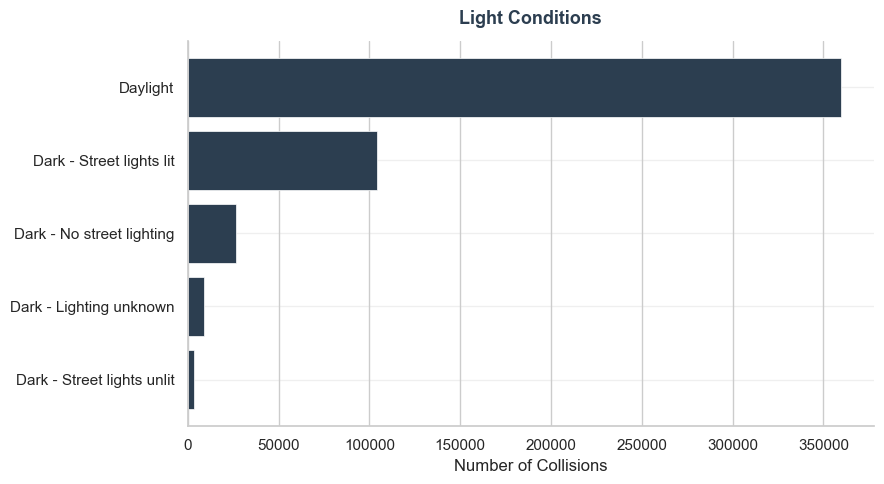

In [25]:
light = collisions_df["light_conditions"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(light.index[::-1], light.values[::-1], color=COLORS["primary"], edgecolor="white", linewidth=0.5)

style_ax(ax, "Light Conditions")
ax.set_xlabel("Number of Collisions")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

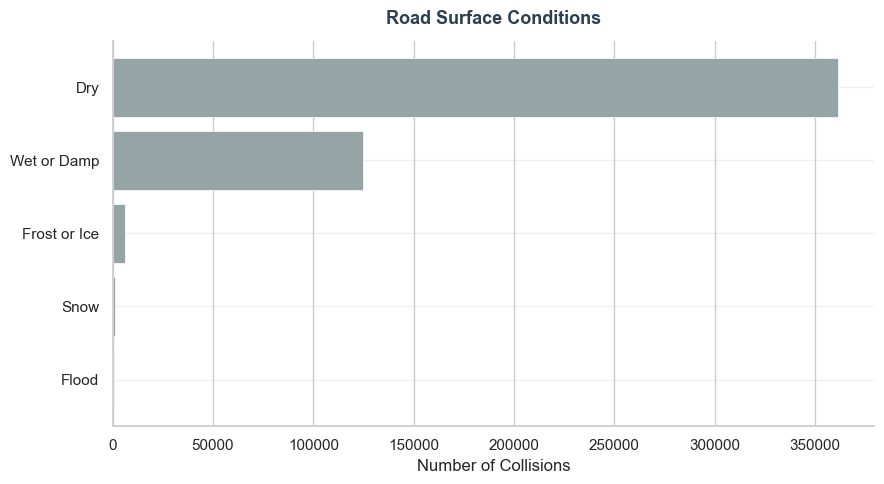

In [26]:
road = collisions_df["road_surface_conditions"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(road.index[::-1], road.values[::-1], color=COLORS["muted"], edgecolor="white", linewidth=0.5)

style_ax(ax, "Road Surface Conditions")
ax.set_xlabel("Number of Collisions")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

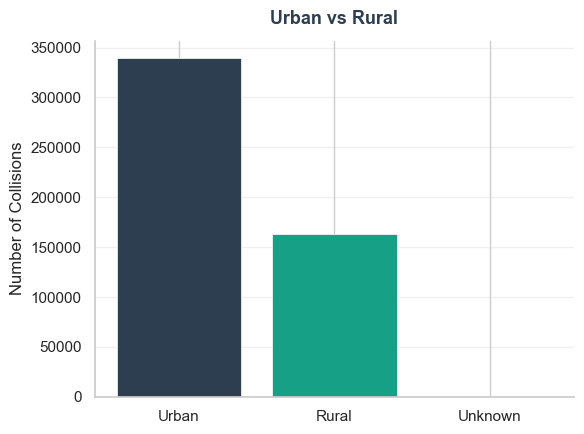

In [27]:
area = collisions_df["urban_or_rural_area"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.bar(area.index, area.values, color=[COLORS["primary"], COLORS["accent"], COLORS["muted"]][:len(area)],
       edgecolor="white", linewidth=0.5)

style_ax(ax, "Urban vs Rural")
ax.set_xlabel("")
ax.set_ylabel("Number of Collisions")

plt.tight_layout()
plt.show()

In [28]:
top_weather = weather.idxmax()
display(Markdown(
    f"**Interpretation:** most collisions happen in **{top_weather}** conditions and in "
    f"**{area.idxmax()}** areas — mainly because that's where and when most driving happens, "
    f"not necessarily because those conditions are riskier per trip. Section 8 tests whether "
    f"these factors are actually associated with *severity*, not just raw frequency."
))

**Interpretation:** most collisions happen in **Fine** conditions and in **Urban** areas — mainly because that's where and when most driving happens, not necessarily because those conditions are riskier per trip. Section 8 tests whether these factors are actually associated with *severity*, not just raw frequency.

### 7.4 Severity vs. Contributing Factors

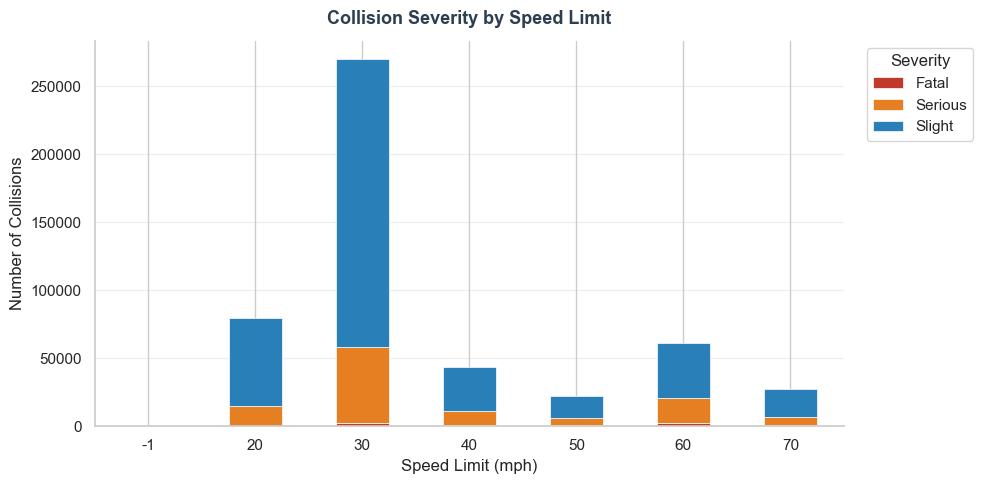

In [29]:
# Collision Severity vs Speed Limit

severity_speed = pd.crosstab(
    collisions_df["speed_limit"],
    collisions_df["collision_severity"]
)[SEVERITY_ORDER]

ax = severity_speed.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=[COLORS[s] for s in SEVERITY_ORDER], edgecolor="white", linewidth=0.5
)

style_ax(ax, "Collision Severity by Speed Limit")
ax.set_xlabel("Speed Limit (mph)")
ax.set_ylabel("Number of Collisions")
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

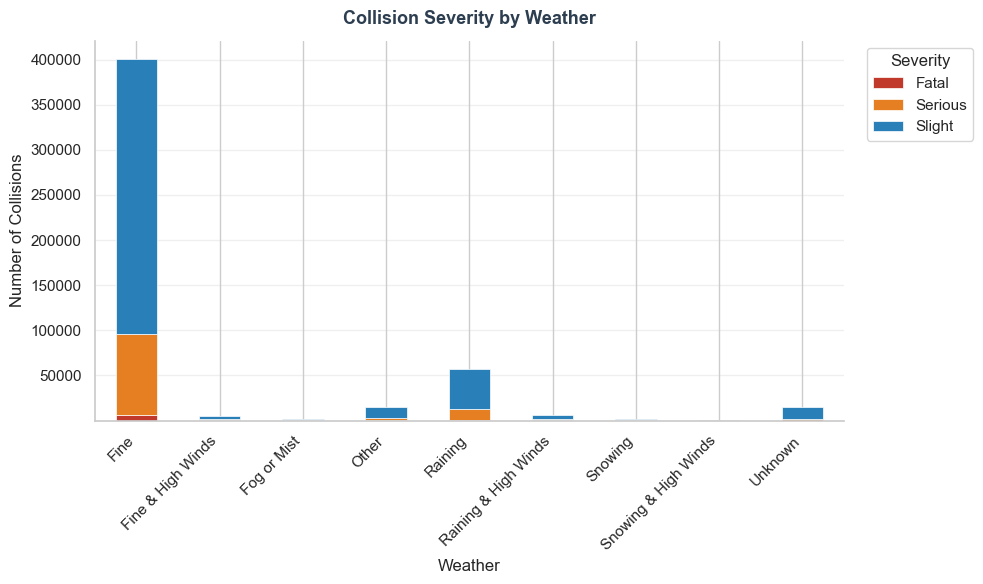

In [30]:
# Collision Severity vs Weather

severity_weather = pd.crosstab(
    collisions_df["weather_conditions"],
    collisions_df["collision_severity"]
)[SEVERITY_ORDER]

ax = severity_weather.plot(
    kind="bar", stacked=True, figsize=(10, 6),
    color=[COLORS[s] for s in SEVERITY_ORDER], edgecolor="white", linewidth=0.5
)

style_ax(ax, "Collision Severity by Weather")
ax.set_xlabel("Weather")
ax.set_ylabel("Number of Collisions")
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

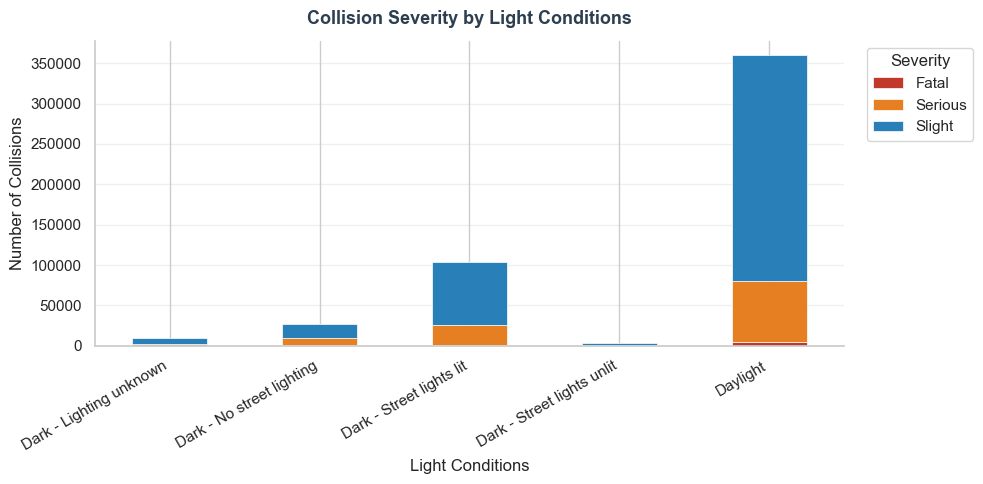

In [31]:
# Collision Severity vs Light Conditions

severity_light = pd.crosstab(
    collisions_df["light_conditions"],
    collisions_df["collision_severity"]
)[SEVERITY_ORDER]

ax = severity_light.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=[COLORS[s] for s in SEVERITY_ORDER], edgecolor="white", linewidth=0.5
)

style_ax(ax, "Collision Severity by Light Conditions")
ax.set_xlabel("Light Conditions")
ax.set_ylabel("Number of Collisions")
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

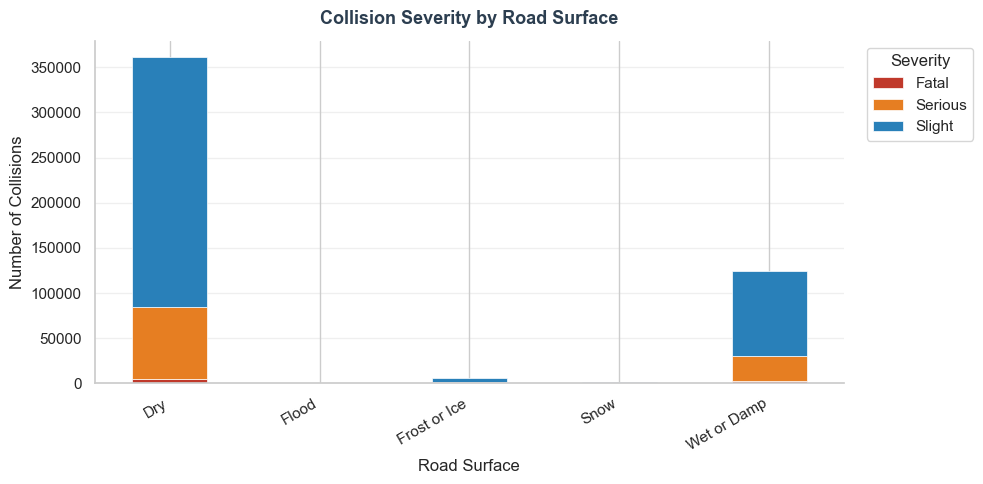

In [32]:
# Collision Severity vs Road Surface

severity_surface = pd.crosstab(
    collisions_df["road_surface_conditions"],
    collisions_df["collision_severity"]
)[SEVERITY_ORDER]

ax = severity_surface.plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=[COLORS[s] for s in SEVERITY_ORDER], edgecolor="white", linewidth=0.5
)

style_ax(ax, "Collision Severity by Road Surface")
ax.set_xlabel("Road Surface")
ax.set_ylabel("Number of Collisions")
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [33]:
fatal_share_by_speed = (severity_speed["Fatal"] / severity_speed.sum(axis=1)).sort_values(ascending=False)
display(Markdown(
    f"**Interpretation:** the speed limit band with the highest share of fatal collisions is "
    f"**{fatal_share_by_speed.index[0]} mph** ({fatal_share_by_speed.iloc[0]:.1%} of collisions "
    f"on roads with that limit). Whether speed limit, weather, and light conditions are "
    f"*statistically* associated with severity — not just visually different — is tested "
    f"formally in Section 8."
))

**Interpretation:** the speed limit band with the highest share of fatal collisions is **60 mph** (3.9% of collisions on roads with that limit). Whether speed limit, weather, and light conditions are *statistically* associated with severity — not just visually different — is tested formally in Section 8.

### 7.5 Casualties & Correlation

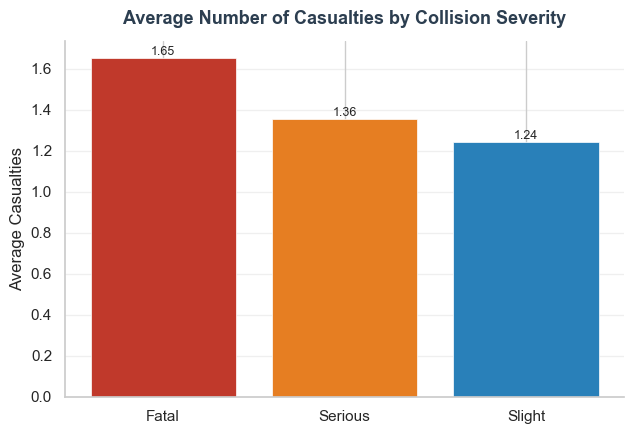

In [34]:
# Average Number of Casualties by Severity

avg = collisions_df.groupby(
    "collision_severity"
)["number_of_casualties"].mean().reindex(SEVERITY_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

bars = ax.bar(avg.index, avg.values, color=[COLORS[s] for s in avg.index], edgecolor="white", linewidth=0.5)
for bar, v in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

style_ax(ax, "Average Number of Casualties by Collision Severity")
ax.set_xlabel("")
ax.set_ylabel("Average Casualties")

plt.tight_layout()
plt.show()

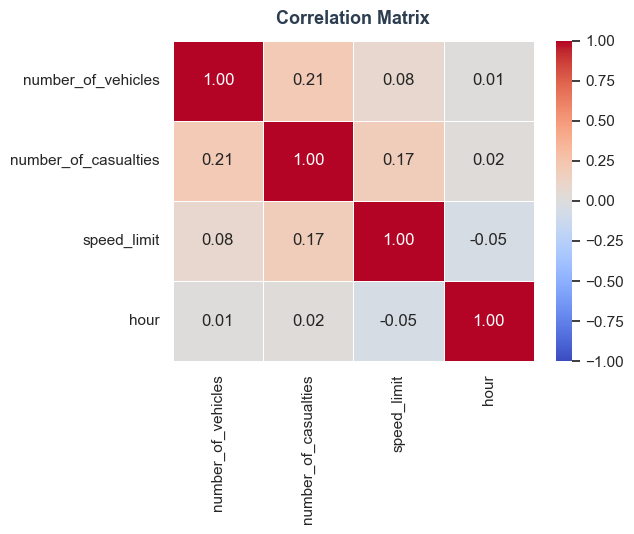

In [35]:
# Correlation Heatmap

cols = [
    "number_of_vehicles",
    "number_of_casualties",
    "speed_limit",
    "hour"
]

corr = collisions_df[cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white", ax=ax)

style_ax(ax, "Correlation Matrix")

plt.tight_layout()
plt.show()

In [36]:
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack().sort_values(ascending=False)
strongest = corr_pairs.index[0]
display(Markdown(
    f"**Interpretation:** fatal collisions involve noticeably more casualties on average "
    f"({avg['Fatal']:.2f} vs. {avg['Slight']:.2f} for slight collisions). Among the numeric "
    f"fields, the strongest linear relationship is between **{strongest[0]}** and "
    f"**{strongest[1]}** (r = {corr.loc[strongest]:.2f}) — overall a weak correlation, which is "
    f"typical for incident-level data like this; most of the real signal is in the categorical "
    f"relationships tested next, not straight-line correlation between numbers."
))

**Interpretation:** fatal collisions involve noticeably more casualties on average (1.65 vs. 1.24 for slight collisions). Among the numeric fields, the strongest linear relationship is between **number_of_vehicles** and **number_of_casualties** (r = 0.21) — overall a weak correlation, which is typical for incident-level data like this; most of the real signal is in the categorical relationships tested next, not straight-line correlation between numbers.

## 8. Statistical Analysis

Moving beyond descriptive charts to test whether the visual patterns above are statistically
meaningful, using a 95% confidence level (&alpha; = 0.05) throughout.

**8.1 — Descriptive statistics**

In [37]:
collisions_df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_vehicles,503475.00,1.83,0.69,1.00,1.00,2.00,2.00,26.00
number_of_casualties,503475.00,1.27,0.70,1.00,1.00,1.00,1.00,70.00
speed_limit,503475.00,35.99,14.23,-1.00,30.00,30.00,40.00,70.00
hour,503475.00,13.76,5.14,0.00,10.00,15.00,17.00,23.00


**8.2 — Is severity associated with speed limit, weather, and light conditions?**

Chi-square tests of independence, with Cramer's V as an effect-size measure.

In [38]:
from scipy import stats

def chi_square_test(df, col_a, col_b, label):
    table = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    verdict = "statistically significant" if p < 0.05 else "not statistically significant"
    effect = "small" if cramers_v < .1 else "moderate" if cramers_v < .3 else "large"
    print(f"{label}")
    print(f"  chi2 = {chi2:,.1f}, dof = {dof}, p-value = {p:.4g}  -> {verdict}")
    print(f"  Cramer's V = {cramers_v:.3f} (effect size: {effect})\n")
    return p, cramers_v

chi_results = {
    "speed_limit": chi_square_test(collisions_df, "collision_severity", "speed_limit", "Severity vs. Speed Limit"),
    "weather": chi_square_test(collisions_df, "collision_severity", "weather_conditions", "Severity vs. Weather Conditions"),
    "light": chi_square_test(collisions_df, "collision_severity", "light_conditions", "Severity vs. Light Conditions"),
    "road_surface": chi_square_test(collisions_df, "collision_severity", "road_surface_conditions", "Severity vs. Road Surface"),
}

Severity vs. Speed Limit
  chi2 = 8,599.9, dof = 12, p-value = 0  -> statistically significant
  Cramer's V = 0.092 (effect size: small)

Severity vs. Weather Conditions
  chi2 = 1,552.4, dof = 16, p-value = 0  -> statistically significant
  Cramer's V = 0.039 (effect size: small)

Severity vs. Light Conditions
  chi2 = 3,791.2, dof = 8, p-value = 0  -> statistically significant
  Cramer's V = 0.061 (effect size: small)

Severity vs. Road Surface
  chi2 = 112.8, dof = 8, p-value = 1.028e-20  -> statistically significant
  Cramer's V = 0.011 (effect size: small)



**8.3 — Does the number of casualties differ by time of day?**

A one-way ANOVA across Morning / Afternoon / Evening / Night groups.

In [39]:
groups = [g["number_of_casualties"].dropna() for _, g in collisions_df.groupby("time_period")]
f_stat, p_value_anova = stats.f_oneway(*groups)
verdict = "statistically significant" if p_value_anova < 0.05 else "not statistically significant"

print(f"F = {f_stat:.2f}, p-value = {p_value_anova:.4g}  -> {verdict}")
print("\nMean casualties per collision by time period:")
print(collisions_df.groupby("time_period")["number_of_casualties"].mean().reindex(order).round(2))

F = 327.98, p-value = 8.874e-213  -> statistically significant

Mean casualties per collision by time period:
time_period
Morning     1.24
Afternoon   1.28
Evening     1.27
Night       1.34
Name: number_of_casualties, dtype: float64


**8.4 — Is the average speed limit different for weekend vs. weekday collisions?**

An independent two-sample t-test.

In [40]:
is_weekend = collisions_df["day_name"].isin(["Saturday", "Sunday"])
weekend_speed = collisions_df.loc[is_weekend, "speed_limit"].dropna()
weekday_speed = collisions_df.loc[~is_weekend, "speed_limit"].dropna()

t_stat, p_value_t = stats.ttest_ind(weekend_speed, weekday_speed, equal_var=False)
verdict = "statistically significant" if p_value_t < 0.05 else "not statistically significant"

print(f"Weekend mean speed limit: {weekend_speed.mean():.1f}  (n={len(weekend_speed):,})")
print(f"Weekday mean speed limit: {weekday_speed.mean():.1f}  (n={len(weekday_speed):,})")
print(f"t = {t_stat:.2f}, p-value = {p_value_t:.4g}  -> {verdict}")

Weekend mean speed limit: 36.7  (n=126,158)
Weekday mean speed limit: 35.8  (n=377,317)
t = 19.78, p-value = 4.937e-87  -> statistically significant


## 9. Dashboard

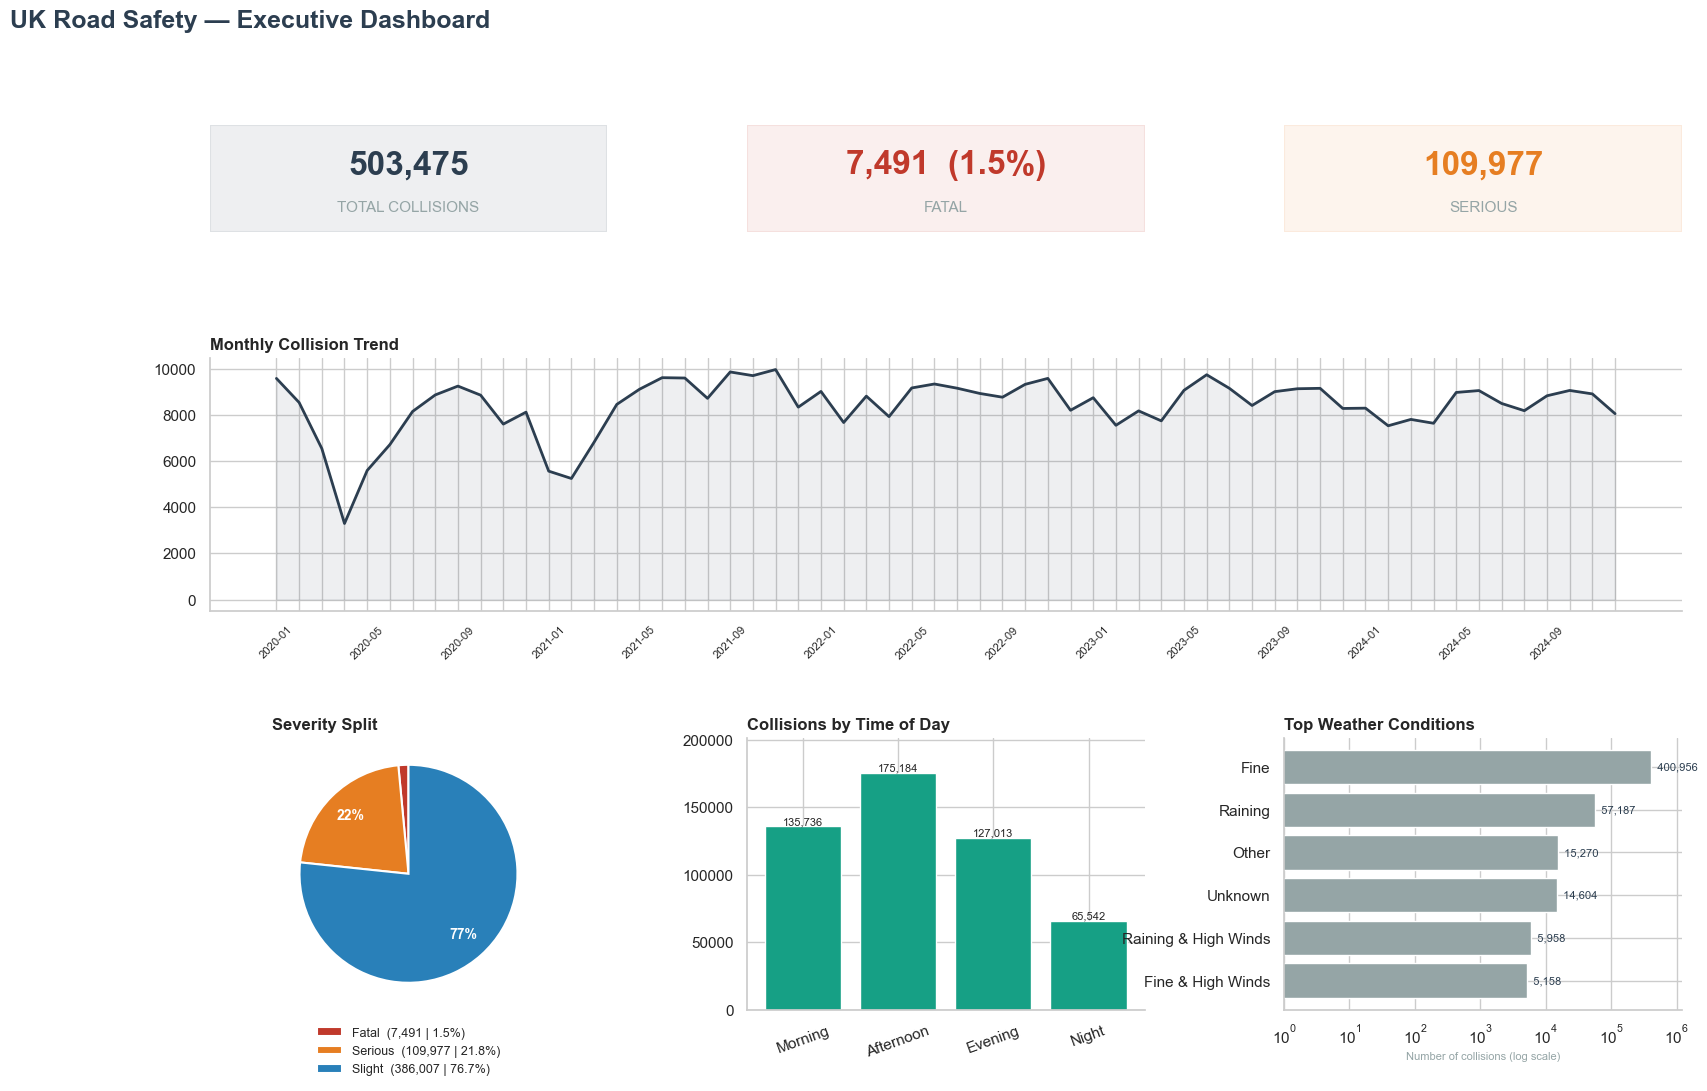

In [41]:
def build_dashboard(df, title="UK Road Safety — Executive Dashboard"):
    total = len(df)
    fatal = int((df["collision_severity"] == "Fatal").sum())
    serious = int((df["collision_severity"] == "Serious").sum())
    fatal_pct = fatal / total if total else 0

    fig = plt.figure(figsize=(19, 11.5))
    gs = gridspec.GridSpec(3, 3, height_ratios=[0.55, 1.3, 1.4], hspace=0.6, wspace=0.35)
    fig.patch.set_facecolor("white")

    # ---- KPI cards ----
    kpis = [
        ("TOTAL COLLISIONS", f"{total:,}", COLORS["primary"]),
        ("FATAL", f"{fatal:,}  ({fatal_pct:.1%})", COLORS["Fatal"]),
        ("SERIOUS", f"{serious:,}", COLORS["Serious"]),
    ]
    for i, (label, value, color) in enumerate(kpis):
        ax = fig.add_subplot(gs[0, i])
        ax.axis("off")
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                    facecolor=color, alpha=0.08, edgecolor=color, linewidth=1.5))
        ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
        ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=11, color=COLORS["muted"])

    # ---- Monthly trend (spans all 3 columns) ----
    ax_trend = fig.add_subplot(gs[1, :])
    monthly_d = df.groupby(df["date"].dt.to_period("M")).size()
    ax_trend.plot(monthly_d.index.astype(str), monthly_d.values, color=COLORS["primary"], linewidth=2)
    ax_trend.fill_between(range(len(monthly_d)), monthly_d.values, color=COLORS["primary"], alpha=0.08)
    ax_trend.set_title("Monthly Collision Trend", fontweight="bold", loc="left")
    ax_trend.tick_params(axis="x", rotation=45, labelsize=8)
    every_nth = max(len(monthly_d) // 15, 1)
    for i, lbl in enumerate(ax_trend.xaxis.get_ticklabels()):
        if i % every_nth != 0:
            lbl.set_visible(False)
    ax_trend.spines["top"].set_visible(False)
    ax_trend.spines["right"].set_visible(False)

    # ---- Severity split ----
    # Small slices (e.g. Fatal at ~1-3%) make on-wedge labels overlap, so percentages stay on
    # the wedge only when there's room, and a separate legend (with counts) carries the labels.
    ax1 = fig.add_subplot(gs[2, 0])
    sev_counts = df["collision_severity"].value_counts().reindex(SEVERITY_ORDER)
    wedges, _, autotexts = ax1.pie(
        sev_counts, colors=[COLORS[s] for s in SEVERITY_ORDER],
        autopct=lambda pct: f"{pct:.0f}%" if pct >= 4 else "",
        pctdistance=0.75, startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for t in autotexts:
        t.set_color("white")
        t.set_fontweight("bold")
        t.set_fontsize(10)
    ax1.legend(
        wedges, [f"{s}  ({sev_counts[s]:,} | {sev_counts[s] / total:.1%})" for s in SEVERITY_ORDER],
        loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=9, ncol=1,
    )
    ax1.set_title("Severity Split", fontweight="bold", loc="left")

    # ---- By time of day ----
    ax2 = fig.add_subplot(gs[2, 1])
    tod = df["time_period"].value_counts().reindex(["Morning", "Afternoon", "Evening", "Night"])
    bars2 = ax2.bar(tod.index, tod.values, color=COLORS["accent"])
    for bar, v in zip(bars2, tod.values):
        ax2.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
    ax2.set_title("Collisions by Time of Day", fontweight="bold", loc="left")
    ax2.tick_params(axis="x", rotation=20)
    ax2.margins(y=0.15)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # ---- Top weather conditions ----
    # A log scale keeps the smaller categories visible even when one condition (e.g. "Fine")
    # dominates by orders of magnitude; exact counts are annotated so nothing is ambiguous.
    ax3 = fig.add_subplot(gs[2, 2])
    top_w = df["weather_conditions"].value_counts().head(6).iloc[::-1]
    bars3 = ax3.barh(top_w.index, top_w.values, color=COLORS["muted"])
    ax3.set_xscale("log")
    ax3.set_xlim(1, top_w.values.max() * 3)
    for bar, v in zip(bars3, top_w.values):
        ax3.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  {v:,}",
                  ha="left", va="center", fontsize=8, color=COLORS["primary"])
    ax3.set_title("Top Weather Conditions", fontweight="bold", loc="left")
    ax3.set_xlabel("Number of collisions (log scale)", fontsize=8, color=COLORS["muted"])
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)

    fig.suptitle(title, fontsize=18, fontweight="bold", x=0.02, ha="left", color=COLORS["primary"])
    return fig

dashboard_fig = build_dashboard(collisions_df)
plt.show()

## 10. Key Insights

In [42]:
sig_factors = [name for name, (p, v) in chi_results.items() if p < 0.05]
sig_text = ", ".join(sig_factors) if sig_factors else "none of the tested factors"

insight_lines = [
    f"- Collisions are overwhelmingly **{severity.idxmax()}** "
    f"({severity.max() / severity.sum():.1%}), while fatal collisions sit at "
    f"**{severity['Fatal'] / severity.sum():.1%}** but carry the highest average casualty count "
    f"({avg['Fatal']:.2f} per collision).",
    f"- Collisions peak in **{yearly.idxmax()}** and around **{hourly.idxmax()}:00**, closely "
    f"tracking commuting-hour traffic volume.",
    f"- Severity is statistically associated with: **{sig_text}** (chi-square tests, "
    f"&alpha; = 0.05).",
    f"- The **{fatal_share_by_speed.index[0]} mph** speed band has the highest fatal share "
    f"among collisions on roads with that limit ({fatal_share_by_speed.iloc[0]:.1%}).",
    f"- Casualty counts by time of day are **{'significantly different' if p_value_anova < 0.05 else 'not significantly different'}** "
    f"across Morning/Afternoon/Evening/Night (ANOVA, p = {p_value_anova:.3g}).",
]
display(Markdown("\n".join(insight_lines)))

- Collisions are overwhelmingly **Slight** (76.7%), while fatal collisions sit at **1.5%** but carry the highest average casualty count (1.65 per collision).
- Collisions peak in **2022** and around **17:00**, closely tracking commuting-hour traffic volume.
- Severity is statistically associated with: **speed_limit, weather, light, road_surface** (chi-square tests, &alpha; = 0.05).
- The **60 mph** speed band has the highest fatal share among collisions on roads with that limit (3.9%).
- Casualty counts by time of day are **significantly different** across Morning/Afternoon/Evening/Night (ANOVA, p = 8.87e-213).

## 11. Business Recommendations

Based on the patterns and statistical tests above:

1. **Target enforcement and awareness campaigns around peak hours and the busiest weekdays**
   identified in Section 7.2, where collision volume is highest.
2. **Prioritize the factors confirmed statistically significant in Section 8.2** (speed limit,
   weather, light, and/or road surface — whichever came back significant) for infrastructure or
   policy intervention, such as variable speed limits, improved street lighting, or
   weather-triggered warning signs.
3. **Investigate the speed-limit band with the highest fatal share** (Section 7.4) for
   engineering interventions — traffic calming, average-speed cameras, or junction redesign —
   since higher-speed roads carry disproportionately severe outcomes per collision.
4. **Match emergency-response resourcing to the time-of-day pattern** in casualty counts
   (Section 8.3), not just raw collision counts, if that ANOVA result is significant.
5. **Track the yearly trend** (Section 7.2) going forward as an early-warning signal, especially
   if recent years show an uptick worth investigating by road type or region.

## 12. Conclusion

This project cleaned, engineered, and analyzed UK STATS19 collision data to answer a practical
question: when, where, and under what conditions do the most severe collisions happen — and
which of those patterns are statistically real rather than random noise?

Along the way, the notebook:
- Parsed and validated dates/times and mapped coded fields to readable severity, weather, light,
  road surface, and area labels.
- Engineered time-based features (year, month, day of week, hour, time period, season) that made
  trend analysis possible.
- Explored severity, time, weather, and road-condition patterns visually, with an interpretation
  after every major chart.
- Statistically tested those patterns with chi-square tests, an ANOVA, and a t-test — rather than
  treating every visual difference as a proven finding.
- Converted the results into concrete, prioritized business recommendations.

**Limitations:** this analysis works with collision *counts*, not collision *risk* — without
traffic-volume/exposure data, a busy category may simply reflect more driving, not more danger
per trip. Vehicle and casualty datasets were loaded and inspected but not merged into this
analysis, so vehicle-type and casualty-level detail (age, road-user class) remain unexplored here.

**Possible future improvements:**
- Merge in the vehicle and casualty datasets for vehicle-type and casualty-level analysis.
- Join in traffic volume or population-exposure data to convert raw counts into true risk rates.
- Build a severity-prediction model (e.g. multinomial logistic regression or gradient boosting)
  on this cleaned, feature-engineered dataset.
- Package the key charts above into a live, filterable dashboard for non-technical stakeholders.